Import libraries and functions

In [1]:
# Import

# Import Python standard libraries
import json  # Import json module for parsing JSON data
import logging  # Import logging module for event logging
from pathlib import Path  # Import Path class from pathlib module for handling file paths
from typing import Union, List, Optional  # Import type hinting classes rrom typing module
from urllib.parse import urlparse  # Import urlparse function from urllib.parse module for identifying URLs

# Import external packages
import requests  # Import Requests library for downloading from URLs
import networkx as nx  # Import NetworkX package for network creation

Configure logging

In [2]:
# Configure logging

logging.basicConfig(
    level=logging.DEBUG,  # Set minimum severity level
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'  # Format log message
)

logger = logging.getLogger('affiliation_builder')  # Create package logger instance

Define build() function

In [ ]:
# Define build() function

def build(  
    json_path: Union[str, Path],
    node_set_0_key: Optional[str],
    node_set_1_keys: Union[str, List[str]],
    identifier_key: str,
    node_set_1_identifier_key: Optional[str] = None
) -> nx.Graph:
    """
    Build a bipartite affiliation network from JSON data.
    
    Creates a bipartite NetworkX graph where node set 0 (e.g., events) connects
    to node set 1 (e.g., human and organization participants in event) through
    affiliation relationships.
    All JSON fields are preserved as node attributes.
    
    Parameters
    ----------
    json_path : str or Path
        Path to JSON file or URL (http/https).
    node_set_0_key : str or None
        JSON key containing node-set-0 items (NetworkX bipartite=0). 
        Use None if JSON is a direct array without a wrapping key.
    node_set_1_keys : str or list of str
        JSON key(s) for affiliated entities (NetworkX bipartite=1) in each node-set-0
        item.
    identifier_key : str
        JSON key to use as unique identifier for node-set-0 items.
    node_set_1_identifier_key : str or None, default=None
        JSON key to use as identifier for node set 1 items when they are objects
        (rather than simple values).
        If None, assumes node set 1 items are simple values (strings/numbers).
        If provided, extracts this key from each entity object and preserves
        all other keys as node attributes.
                
    Returns
    -------
    networkx.Graph
        Bipartite graph with two node sets connected by affiliation edges.
        
    Examples
    --------
    >>> # Simple entities (strings)
    >>> G = build('events.json', 'events', 'participants', 'name')
    
    >>> # Complex entities (objects with metadata)
    >>> G = build(json_path='events.json',
    ...           node_set_0_key='events',
    ...           node_set_1_keys='participants',
    ...           identifier_key='name',
    ...           node_set_1_identifier_key='person_name')
    
    >>> # Direct array format
    >>> G = build('events.json', None, 'members', 'id')
    
    >>> # Multiple entity types with complex objects
    >>> G = build('events.json', 'events', ['persons', 'organizations'], 'name',
    ...           node_set_1_identifier_key='name')
    
    Notes
    -----
    Node set 0 has bipartite=0, node set 1 has bipartite=1. Edges only exist
    between nodes of different sets. Access node sets with:
    
        node_set_0 = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
        node_set_1 = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}

    When node_set_1_identifier_key is specified, all other attributes from entity 
    objects are preserved as node attributes, enabling rich metadata analysis.

    """

    # Log function call and arguments
    logger.info(f"Affiliation network builder started")
    logger.info(f"JSON source: {json_path}")
    logger.info(f"Node-set-0 key: '{node_set_0_key}'")
    logger.info(f"Node-set-1 keys: {node_set_1_keys}")
    logger.info(f"Identifier key: '{identifier_key}'")
    logger.info(f"Node-set-1 identifier key: '{node_set_1_identifier_key}'")

    # =========================================================================
    # Input validation
    # =========================================================================
    
    # Validate input types
    
    # Validate node_set_1_keys type
    if not isinstance(node_set_1_keys, (str, list)):  # Check data type
        logger.error(
            f"Invalid type for node_set_1_keys detected: {type(node_set_1_keys)}"  # Log type error
        )
        raise TypeError(
            f"node_set_1_keys must be string or list, "
            f"but got {type(node_set_1_keys).__name__}"  # Raise type error
        )
    
    # Validate identifier_key type
    if not isinstance(identifier_key, str):
        logger.error(
            f"Invalid type for identifier_key detected: {type(identifier_key)}"
        )
        raise TypeError(
            f"identifier_key must be string, "
            f"but got {type(identifier_key).__name__}"
        )
    
    # Validate node_set_1_identifier_key type (if provided)
    if node_set_1_identifier_key is not None and not isinstance(node_set_1_identifier_key, str):
        logger.error(
            f"Invalid type for node_set_1_identifier_key detected: {type(node_set_1_identifier_key)}"
        )
        raise TypeError(
            f"node_set_1_identifier_key must be string or None, "
            f"but got {type(node_set_1_identifier_key).__name__}"
        )
    
    # Validate node_set_0_key type
    if node_set_0_key is not None and not isinstance(node_set_0_key, str):
        logger.error(
            f"Invalid type for node_set_0_key detected: {type(node_set_0_key)}"
        )
        raise TypeError(
            f"node_set_0_key must be string or None, "
            f"but got {type(node_set_0_key).__name__}"
        )
    
    logger.debug("Input validation passed")

    # =========================================================================
    # STEP 1: Normalize node_set_1_keys to list
    # =========================================================================
    
    # Convert string to list

    if isinstance(node_set_1_keys, str):  # Check for string type
        node_set_1_keys = [node_set_1_keys]  # Convert to list
        logger.debug(f"Converting node_set_1_keys to list: {node_set_1_keys}")  # Log normalization

    # =========================================================================
    # STEP 2: Load JSON data (local file or URL)
    # =========================================================================
    
    # Determine data source and load data.

    is_url = False  # Set local source as default

    # Check URL source
    if isinstance(json_path, str):  # Check for string type
        parsed = urlparse(json_path)  # Parse URL
        is_url = parsed.scheme in ('http', 'https')  # Check URL scheme
    
    # Load from URL

    if is_url:
        logger.info(f"URL source detected, downloading JSON from: {json_path}")  # Log URL detection

        # Load and parse JSON from URL

        try:
            response = requests.get(json_path, timeout=30)  # Send request to server; set timeout to 30 seconds; return Response object
            response.raise_for_status()  # Raise exception for HTTP status code 4xx or 5xx
            data = response.json()  # Decode Response object as UTF-8 text; parse as JSON into Python list or dictionary
            logger.info(f"JSON successfully downloaded") # Log successful download
                        
        except requests.exceptions.Timeout:  # Catch timeout exception
            logger.error(f"Request timed out")  # Log timeout error
            raise requests.exceptions.Timeout(
                f"Request timed out while accessing {json_path}"  # Re-raise with context
            )
        
        except requests.exceptions.ConnectionError as e:
            logger.error(f"Connection error: {e}")  # Log connection error details
            raise requests.exceptions.ConnectionError(
                f"Could not connect to {json_path}"
            )
        
        except requests.exceptions.HTTPError as e:  # Catch HTTP exception raised by response.raise_for_status()
            logger.error(f"HTTP error: {e}")
            raise  # Re-raise without added context (URL already part of original error message)

        except json.JSONDecodeError as e:  # Catch JSON error
            logger.error(f"Downloaded content is not valid JSON")
            raise ValueError(
                f"Downloaded content from {json_path} is not valid JSON: {e.msg}"
            ) from e  # Re-raise as value error with original error message
        
        except requests.exceptions.RequestException as e:  # Catch any other error from Requests library
            logger.error(f"Unexpected error downloading from URL: {e}")
            raise

    # Load locally

    else:
        json_path = Path(json_path)  # Convert string to Path object (if necessary)
        logger.info(f"Local file path detected: {json_path}")  # Log file path detection

        # Check path exists
        if not json_path.exists():
            logger.error(f"File not found: {json_path}")
            raise FileNotFoundError(f"JSON file not found: {json_path}")
        
        # Check path points to file
        if not json_path.is_file():
            logger.error(f"Not a file: {json_path}")
            raise ValueError(
                f"Path must point to a file, not a directory: {json_path}"
            )
        
        # Load and parse JSON from file path

        try:
            with json_path.open('r', encoding='utf-8') as f:  # Open for reading with UTF-8 encoding
                data = json.load(f)  # Parse JSON from file object; return list or dictionary
            
            logger.info(f"Local JSON file successfully loaded")
            
        except json.JSONDecodeError as e:
            logger.error(f"Invalid JSON format in file")
            raise ValueError(
                f"File {json_path} is not valid JSON: {e.msg}"
            ) from e
                
        except UnicodeDecodeError as e:  # Catch encoding error
            logger.error(f"File encoding error: {e}")
            raise ValueError(f"Unable to read file with UTF-8 encoding: {e}")
        
        except Exception as e:  # Catch any other error
            logger.error(f"Unexpected error loading JSON: {e}")
            raise

    # =========================================================================
    # STEP 3: Validate JSON structure and extract items
    # =========================================================================
    
    # Handle both direct arrays and wrapped objects in JSON.
    
    if isinstance(data, list): # Check for direct array format
        items = data  # Use data as-is
        logger.info(f"Direct array format with {len(items)} items detected")  # Log JSON structure
        
    elif isinstance(data, dict):  # Check for wrapped object format
        if node_set_0_key is None:  # Check for node-set-0 key
            logger.error("Wrapped object format detected, but node_set_0_key is None")  # Log missing key error
            raise ValueError(
                f"JSON is a wrapped object. node_set_0_key is required to specify "
                f"key pointing to data. Available keys: {list(data.keys())}"  # Show available keys
            )
        
        if node_set_0_key not in data: # Check node-set-0 key is valid
            logger.error(f"Key '{node_set_0_key}' not found")  # Log invalid key error
            raise ValueError(
                f"The key '{node_set_0_key}' was not found in the JSON data. "
                f"Available keys: {list(data.keys())}" 
            ) # Raise invalid key error

        if not isinstance(data[node_set_0_key], list):  # Check node-set-0 key is list
            logger.error(f"Value for '{node_set_0_key}' is not a list")  # Log invalid value error
            raise ValueError(
                f"The value for '{node_set_0_key}' must be a list, "
                f"but got {type(data[node_set_0_key]).__name__}"
            )  # Raise invalid value error
        
        items = data[node_set_0_key]  # Extract and assign list
        logger.info(f"Wrapped object format with {len(items)} items in '{node_set_0_key}' detected")  # Log successful extraction
                
    else:  # Handle invalid format
        logger.error(f"Unexpected data type: {type(data)}")  # Log invalid data type error
        raise ValueError(
            f"Expected list or dictionary, but got {type(data).__name__}"
        )
        
    if len(items) == 0:  # Check for empty data
        logger.warning(f"No items found in the data")  # Log warning, no error
    
    
    # =========================================================================
    # STEP 4: Create bipartite graph
    # =========================================================================
    
    G = nx.Graph()  # Initialize undirected NetworkX graph
    logger.info("NetworkX graph initialized")  # Log graph initialization
    
    
    # =========================================================================
    # STEP 5: Iterate through items and build network
    # =========================================================================

    for idx, item in enumerate(items):  # Index for logging; loop through index-item pairs

        # Check if item is dictionary
        if not isinstance(item, dict):
            logger.warning(
                f"Item at index {idx} not a dictionary, but {type(item).__name__}, skipping"
            )
            continue  # Continue loop with next item
                
        # Check for node-set-0 key
        if identifier_key not in item:
            logger.warning(
                f"Item at index {idx} missing '{identifier_key}' key, skipping. "
                f"Available keys: {list(item.keys())}"
            )
            continue
        
        node_id = item[identifier_key]  # Get node ID from identifier_key
        
        # Validate node ID
        if node_id is None or node_id == "":
            logger.warning(
                f"Item at index {idx} has empty or None identifier, skipping"
            )
            continue

        # Check if node ID is hashable (for NetworkX node processing)
        try:
            hash(node_id)
        except TypeError:  # Raise TypeError if not hashable
            logger.warning(
                f"Item at index {idx} has unhashable identifier '{node_id}', skipping"
            )
            continue
        
        # Remove entity list keys to avoid redundancy (with edges)
        item_attrs = item.copy()
        for key in node_set_1_keys:
            item_attrs.pop(key, None)

        # Add node-set-0 nodes to graph from IDs
        G.add_node(node_id, bipartite=0, **item_attrs)  # Add node with (non-entity-related) attributes
        logger.debug(f"Node-set-0 node '{node_id}' added")
        
        # Process each entity key
        for key in node_set_1_keys:  # Loop through list of keys
            if key not in item:
                logger.debug(f"Key '{key}' not found in item '{node_id}', skipping")
                continue  # Skip key that's missing in dictionary

            entities = item[key]  # Get entity list
            
            # Check if value is list
            if not isinstance(entities, list):
                logger.warning(
                    f"Value for '{key}' in item '{node_id}' not a list, but {type(entities).__name__}, skipping"
                )
                continue

            for entity in entities:  # Loop through entity list
                
                # Handle entities that are JSON objects

                if isinstance(entity, dict):  # Check if entity is object
                    
                    # Check for identifier key
                    if node_set_1_identifier_key is None:
                        logger.warning(
                            f"Entity in '{key}' for item '{node_id}' is object, "
                            f"but node_set_1_identifier_key is None. Specify which key "
                            f"to use as identifier, skipping: {entity}"
                        )
                        continue

                    # Check for identifier key in entity
                    if node_set_1_identifier_key not in entity:
                        logger.warning(
                            f"Entity in '{key}' for item '{node_id}' missing "
                            f"'{node_set_1_identifier_key}' key, skipping: {entity}"
                        )
                        continue
                    
                    entity_id = entity[node_set_1_identifier_key]  # Get node ID
                    
                    entity_attrs = entity.copy()  # Copy attributes

                else:
                    
                    # Handle entities that are simple JSON values
                    
                    entity_id = entity  # Get node ID
                    
                    entity_attrs = {}  # Create empty dictionary of graph node attributes

                # Validate graph node ID
                if entity_id is None or entity_id == "":
                    logger.warning(
                        f"Entity in '{key}' for item '{node_id}' has empty or None "
                        f"identifier, skipping: {entity}"
                    )
                    continue
                
                try:
                    hash(entity_id)
                except TypeError:
                    logger.warning(
                        f"Entity ID '{entity_id}' in '{key}' for item '{node_id}' "
                        f"is not hashable, skipping"
                    )
                    continue
                
                # Check for duplicate entity and log attribute overwriting
                if entity_id in G:
                    logger.debug(
                        f"Duplicate entity '{entity_id}' found, updating attributes"
                    )

                # Add entity node
                G.add_node(entity_id, bipartite=1, **entity_attrs)
                logger.debug(f"Node-set-1 node '{entity_id}' added")
                
                # Add edge between entity and item
                G.add_edge(node_id, entity_id)
                logger.debug(f"Edge between '{node_id}' and '{entity_id}' added")

    # =========================================================================
    # STEP 6: Log summary and return graph
    # =========================================================================

    # Count nodes in each set
    node_set_0_count = sum(1 for _, d in G.nodes(data=True) if d['bipartite'] == 0)  # Return and unpack (node ID, attributes dictionary) tuples; mark IDs as irrelevant; filter according to node set; count relevant nodes
    node_set_1_count = sum(1 for _, d in G.nodes(data=True) if d['bipartite'] == 1)

    node_set_0_label = f"({node_set_0_key})" if node_set_0_key else "(direct array)"  # Create node-set-0 label

    # Log summary
    logger.info("=" * 60)
    logger.info("BIPARTITE NETWORK CONSTRUCTION COMPLETE")
    logger.info("=" * 60)
    logger.info(f"Total edges (affiliations): {G.number_of_edges()}")  # Log number of edges
    logger.info(f"Total nodes: {G.number_of_nodes()}")  # Log number of nodes
    logger.info(f"Node set 0 {node_set_0_label}: {node_set_0_count} nodes")  # Log number of node-set-0 nodes
    logger.info(f"Node set 1 ({node_set_1_keys}): {node_set_1_count} nodes")  # Log number of node-set-1 nodes
    logger.info("=" * 60)
    
    # Verify graph is bipartite
    if nx.is_bipartite(G):  # Check for bipartite attributes in nodes; check for edges within same node sets
        logger.info("✓ Graph structure is valid bipartite")
    else:
        logger.warning("⚠ Graph is not bipartite! There may be edges within the same set")
    
    return G  # Return NetworkX Graph object


Test build

In [4]:
# Build network from example data

G = build(
    'example.json',
    'events',
    ['persons', 'organizations'],
    'name',
    node_set_1_identifier_key='name'
)

2025-11-19 15:32:25,430 - affiliation_builder - INFO - Affiliation network builder started
2025-11-19 15:32:25,431 - affiliation_builder - INFO - JSON source: example.json
2025-11-19 15:32:25,432 - affiliation_builder - INFO - Node-set-0 key: 'events'
2025-11-19 15:32:25,432 - affiliation_builder - INFO - Node-set-1 keys: ['persons', 'organizations']
2025-11-19 15:32:25,432 - affiliation_builder - INFO - Identifier key: 'name'
2025-11-19 15:32:25,433 - affiliation_builder - INFO - Node-set-1 identifier key: 'name'
2025-11-19 15:32:25,433 - affiliation_builder - DEBUG - Input validation passed
2025-11-19 15:32:25,433 - affiliation_builder - INFO - Local file path detected: example.json
2025-11-19 15:32:25,435 - affiliation_builder - INFO - Local JSON file successfully loaded
2025-11-19 15:32:25,435 - affiliation_builder - INFO - Wrapped object format with 3 items in 'events' detected
2025-11-19 15:32:25,435 - affiliation_builder - INFO - NetworkX graph initialized
2025-11-19 15:32:25,43

Test analysis

In [5]:
print("=" * 60)
print("SIMPLE NETWORK ANALYSIS")
print("=" * 60)

# Overall statistics

print(f"\nNetwork statistics:\n")
print(f"  Nodes total: {G.number_of_nodes()}")
print(f"  Edges total: {G.number_of_edges()}")

node_set_0 = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}  # Create set of node IDs from unpacked (node id, attributes dictionary) tuples
node_set_1 = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}

print(f"\nNode Set 0: {len(node_set_0)} nodes")
for node in sorted(node_set_0):  # Return alphabetical list of node IDs
    print(f"  - {node}")

print(f"\nNode Set 1: {len(node_set_1)} nodes")
for node in sorted(node_set_1):
    print(f"  - {node}")

# Degree analysis

print(f"\nDegree distribution:\n")
print(f"Number of edges connected to node-set-0 nodes:")
for node in sorted(node_set_0):
    degree = G.degree(node)  # Return node degree
    print(f"  - {node}: {degree} connections")

print(f"\nNumber of edges connected to node-set-1 nodes:")
for node in sorted(node_set_1):
    degree = G.degree(node)
    print(f"  - {node}: {degree} connections\n")

print("=" * 60)

SIMPLE NETWORK ANALYSIS

Network statistics:

  Nodes total: 11
  Edges total: 12

Node Set 0: 3 nodes
  - Conference on Digital Humanities 2024
  - TEI Encoding Seminar
  - Workshop on Network Analysis

Node Set 1: 8 nodes
  - Alice Smith
  - Austrian Academy of Sciences
  - Berlin-Brandenburg Academy
  - Bob Jones
  - Carol Williams
  - David Brown
  - Emma Davis
  - University of Vienna

Degree distribution:

Number of edges connected to node-set-0 nodes:
  - Conference on Digital Humanities 2024: 4 connections
  - TEI Encoding Seminar: 4 connections
  - Workshop on Network Analysis: 4 connections

Number of edges connected to node-set-1 nodes:
  - Alice Smith: 2 connections

  - Austrian Academy of Sciences: 2 connections

  - Berlin-Brandenburg Academy: 1 connections

  - Bob Jones: 1 connections

  - Carol Williams: 2 connections

  - David Brown: 1 connections

  - Emma Davis: 1 connections

  - University of Vienna: 2 connections



Test visualization

Note: you may need to restart the kernel to use updated packages.


2025-11-19 15:32:26,442 - matplotlib - DEBUG - matplotlib data path: /home/tfruehwirth/Documents/git-repos/affiliation-builder/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2025-11-19 15:32:26,453 - matplotlib - DEBUG - CONFIGDIR=/home/tfruehwirth/.config/matplotlib
2025-11-19 15:32:26,457 - matplotlib - DEBUG - interactive is False
2025-11-19 15:32:26,458 - matplotlib - DEBUG - platform is linux
2025-11-19 15:32:26,476 - matplotlib - DEBUG - CACHEDIR=/home/tfruehwirth/.cache/matplotlib
2025-11-19 15:32:26,478 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/tfruehwirth/.cache/matplotlib/fontlist-v390.json
2025-11-19 15:32:26,639 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-11-19 15:32:26,642 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-11-19 15:32:26,646 - matplotlib.font_manager - DEBUG - findfont: Matching sans\-serif:style=

Generating network visualization...


2025-11-19 15:32:26,837 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/tfruehwirth/Documents/git-repos/affiliation-builder/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2025-11-19 15:32:26,837 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/tfruehwirth/Documents/git-repos/affiliation-builder/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.335
2025-11-19 15:32:26,837 - matplotlib.font_manager - DEBUG - findfont: score(FontEntry(fname='/home/tfruehwirth/Documents/git-repos/affiliation-builder/venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, str

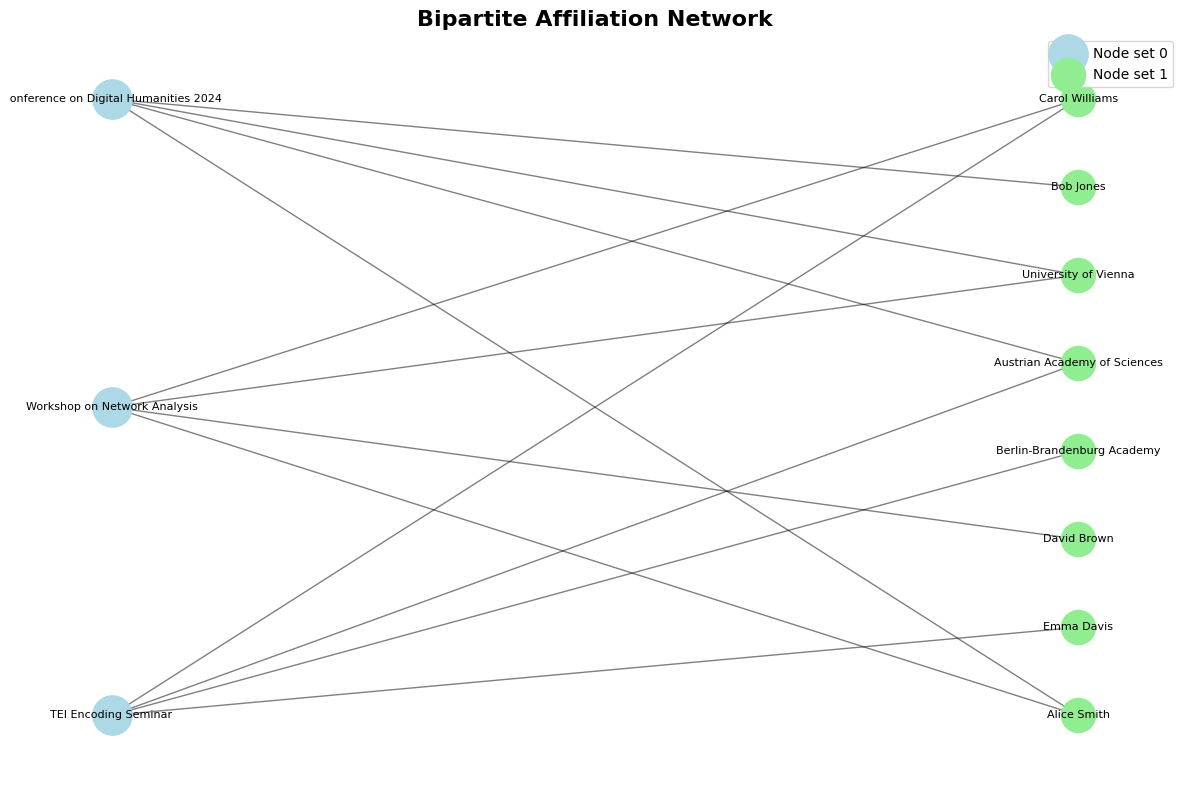

In [6]:
%pip install -q matplotlib  # Quietly install matplotlib library if needed

import matplotlib.pyplot as plt  # Import pyplot module for plotting

print("Generating network visualization...")

plt.figure(figsize=(12, 8))  # Create 12x8 inch figure

pos = nx.bipartite_layout(G, node_set_0)  # Return dictionary with two-column layout; place node-set-0 nodes left

# Draw nodes

nx.draw_networkx_nodes(G, pos,
                       nodelist=node_set_0,
                       node_color='lightblue',
                       node_size=800,  # Set node size
                       label='Node set 0')  # Set legend label

nx.draw_networkx_nodes(G, pos,
                       nodelist=node_set_1,
                       node_color='lightgreen',
                       node_size=600,
                       label='Node set 1')

nx.draw_networkx_edges(G, pos, alpha=0.5)  # Draw edges at 50% transparency

nx.draw_networkx_labels(G, pos, font_size=8)  # Draw node labels from node IDs

# Add title and legend
plt.title("Bipartite Affiliation Network", fontsize=16, fontweight='bold')
plt.legend(loc='upper right')  # Place legend
plt.axis('off')  # Hide axes
plt.tight_layout()  # Automatically adjust spacing
plt.show()